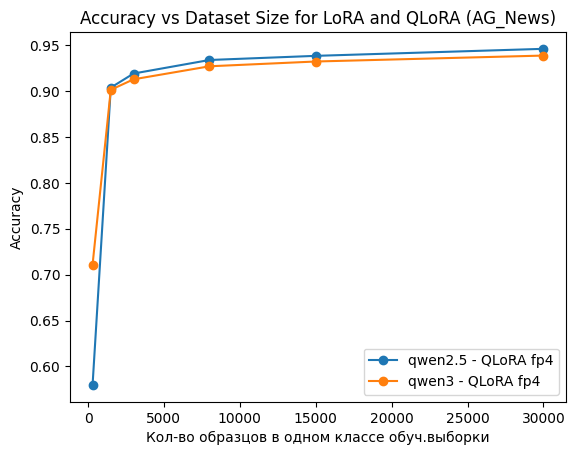

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('all_exp_results.csv')
df = df[df['dataset'] == "EN"]

# Фильтрация моделей и методов
df_filtered = df[
    (df['model'].isin(['qwen2.5', 'qwen3'])) &
    (df['method'].isin(['QLoRA fp4']))
]

# Усреднение accuracy
df_avg = (
    df_filtered
    .groupby(['model', 'method', 'pst_dataset'])['accuracy']
    .mean()
    .reset_index()
)

# Построение графика
plt.figure()

for (model, method), group in df_avg.groupby(['model', 'method']):
    label = f"{model} - {method}"
    plt.plot(group['pst_dataset'], group['accuracy'], marker='o', label=label)

plt.xlabel('Кол-во образцов в одном классе обуч.выборки')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Dataset Size for LoRA and QLoRA (AG_News)')
plt.legend()

plt.show()

In [13]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('all_exp_results.csv')

# Фильтрация только нужных моделей
df_filtered = df[df['model'].isin(['qwen2.5', 'qwen3'])]

# Считаем стандартное отклонение loss
stability = (
    df_filtered
    .groupby(['model'])['loss']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .reset_index()
)

print(stability)

     model      mean        std       min    max  count
0  qwen2.5  6.723886  40.973961  0.252099  580.5    333
1    qwen3  0.542093   0.960888  0.257335   20.0    441


In [14]:
# Стабильность при одинаковом размере датасета и методе
stability_detailed = (
    df_filtered
    .groupby(['model', 'method', 'pst_dataset'])['loss']
    .std()
    .reset_index()
)

# Средний разброс по всем условиям
stability_mean = (
    stability_detailed
    .groupby('model')['loss']
    .mean()
    .reset_index(name='avg_std_loss')
)

print(stability_mean)

     model  avg_std_loss
0  qwen2.5     25.441946
1    qwen3      0.241198


In [15]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('all_exp_results.csv')

# Оставляем нужные модели
df_filtered = df[df['model'].isin(['qwen2.5', 'qwen3'])]

# Среднее потребление памяти
memory_stats = (
    df_filtered
    .groupby('model')['gpu']
    .agg(['mean', 'min', 'max', 'std'])
    .reset_index()
)

print(memory_stats)

     model      mean       min        max       std
0  qwen2.5  5.117096  2.876214  11.909000  1.806078
1    qwen3  3.242819  1.289078   5.790635  0.762732


In [16]:
# Сравнение при одинаковых настройках
memory_detailed = (
    df_filtered
    .groupby(['model', 'method', 'pst_dataset'])['gpu']
    .mean()
    .reset_index()
)

# Усредняем по всем условиям
memory_final = (
    memory_detailed
    .groupby('model')['gpu']
    .mean()
    .reset_index(name='avg')
)

print(memory_final)

     model       avg
0  qwen2.5  5.406518
1    qwen3  2.968370


/tmp/ipykernel_5665/4019788645.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


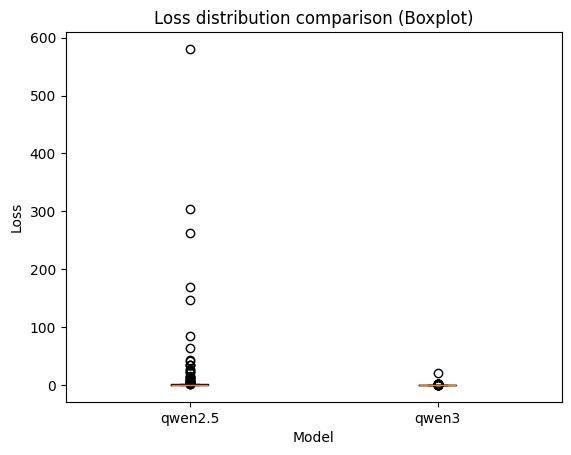

In [17]:
import matplotlib.pyplot as plt

plt.figure()

# Подготовка данных
data = []
labels = []

for model, group in df_filtered.groupby('model'):
    data.append(group['loss'].dropna())
    labels.append(model)

# Boxplot
plt.boxplot(data, labels=labels)

plt.xlabel('Model')
plt.ylabel('Loss')
plt.title('Loss distribution comparison (Boxplot)')

plt.show()

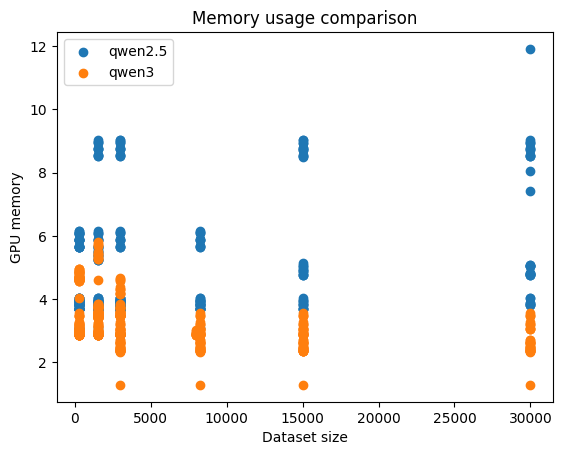

In [18]:
import matplotlib.pyplot as plt

plt.figure()

for model, group in df_filtered.groupby('model'):
    plt.scatter(group['pst_dataset'], group['gpu'], label=model)

plt.xlabel('Dataset size')
plt.ylabel('GPU memory')
plt.title('Memory usage comparison')
plt.legend()

plt.show()

In [19]:
import pandas as pd

df = pd.read_csv('all_exp_results.csv')

df_filtered = df[df['model'].isin(['qwen2.5', 'qwen3'])]

# Среднее время обучения
speed_stats = (
    df_filtered
    .groupby('model')['gpu']
    .agg(['mean', 'min', 'max', 'std'])
    .reset_index()
)

print(speed_stats)

     model      mean       min        max       std
0  qwen2.5  5.117096  2.876214  11.909000  1.806078
1    qwen3  3.242819  1.289078   5.790635  0.762732


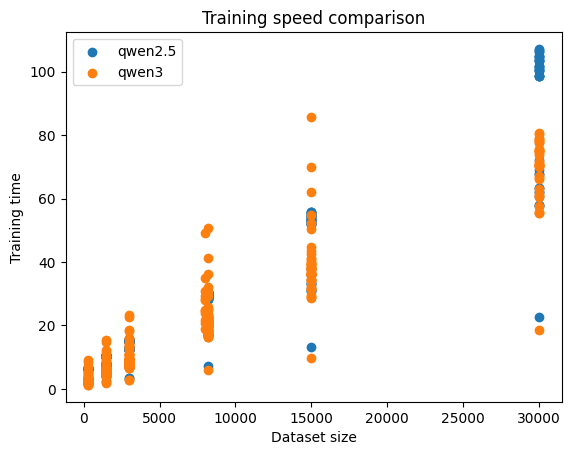

In [20]:
import matplotlib.pyplot as plt

plt.figure()

for model, group in df_filtered.groupby('model'):
    plt.scatter(group['pst_dataset'], group['time'], label=model)

plt.xlabel('Dataset size')
plt.ylabel('Training time')
plt.title('Training speed comparison')
plt.legend()

plt.show()

In [21]:
# скорость = сколько данных обрабатывается за единицу времени
df_filtered['speed'] = df_filtered['pst_dataset'] / df_filtered['time']

speed_norm = (
    df_filtered
    .groupby('model')['speed']
    .mean()
    .reset_index()
)

print(speed_norm)

     model       speed
0  qwen2.5  255.932783
1    qwen3  301.569567


In [23]:
import pandas as pd

df = pd.read_csv('all_exp_results.csv')

# Берём только LoRA/QLoRA и строки с rank
df_rank = df[
    (df['method'].isin(['LoRA', 'QLoRA'])) &
    (df['rank'].notna())
]

In [24]:
rank_stats = (
    df_rank
    .groupby('rank')['accuracy']
    .mean()
    .reset_index()
    .sort_values('rank')
)

print(rank_stats)

   rank  accuracy
0   4.0  0.842609
1   8.0  0.855534
2  16.0  0.874218
3  32.0  0.892652


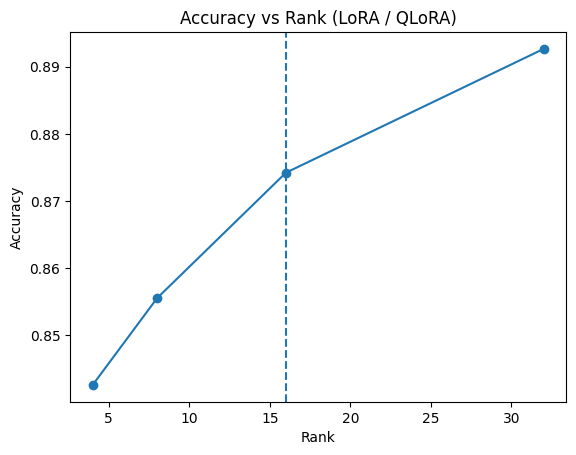

In [25]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(rank_stats['rank'], rank_stats['accuracy'], marker='o')

plt.xlabel('Rank')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Rank (LoRA / QLoRA)')

plt.axvline(x=16, linestyle='--')  # важная граница

plt.show()

In [26]:
rank_stats['delta'] = rank_stats['accuracy'].diff()

print(rank_stats)

   rank  accuracy     delta
0   4.0  0.842609       NaN
1   8.0  0.855534  0.012924
2  16.0  0.874218  0.018684
3  32.0  0.892652  0.018434


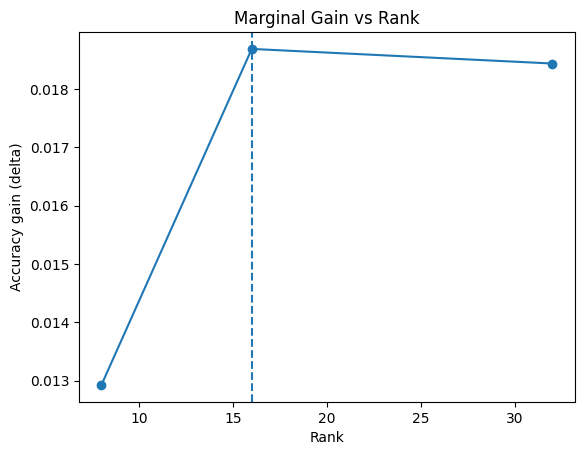

In [27]:
plt.figure()

plt.plot(rank_stats['rank'], rank_stats['delta'], marker='o')

plt.xlabel('Rank')
plt.ylabel('Accuracy gain (delta)')
plt.title('Marginal Gain vs Rank')

plt.axvline(x=16, linestyle='--')

plt.show()

In [28]:
import pandas as pd

df = pd.read_csv('all_exp_results.csv')

# Только baseline
df_base = df[df['method'] == 'baseline']

# Только нужные модели
df_base = df_base[df_base['model'].isin(['qwen2.5', 'qwen3'])]

In [29]:
baseline_stats = (
    df_base
    .groupby('model')[['accuracy', 'f1', 'loss']]
    .agg(['mean', 'std', 'min', 'max'])
)

print(baseline_stats)

         accuracy                                      f1                      \
             mean       std       min       max      mean       std       min   
model                                                                           
qwen2.5  0.602094  0.146801  0.470044  0.856308  0.596951  0.150971  0.455729   
qwen3    0.737756  0.148559  0.468095  0.881711  0.736167  0.151090  0.456688   

                         loss                                    
              max        mean         std       min         max  
model                                                            
qwen2.5  0.855917  172.413081  190.073615  0.435303  580.500000  
qwen3    0.881535    0.706136    0.322046  0.412598    1.261719  


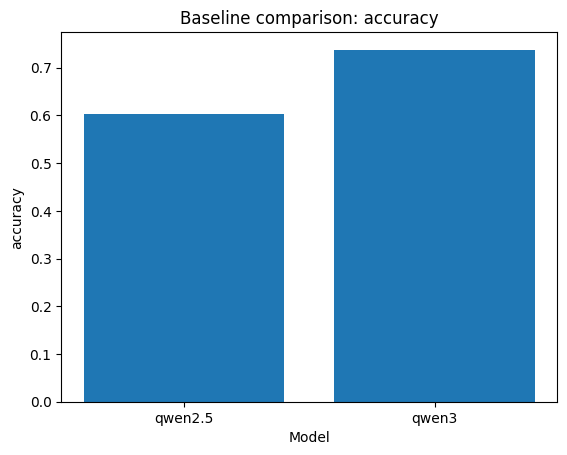

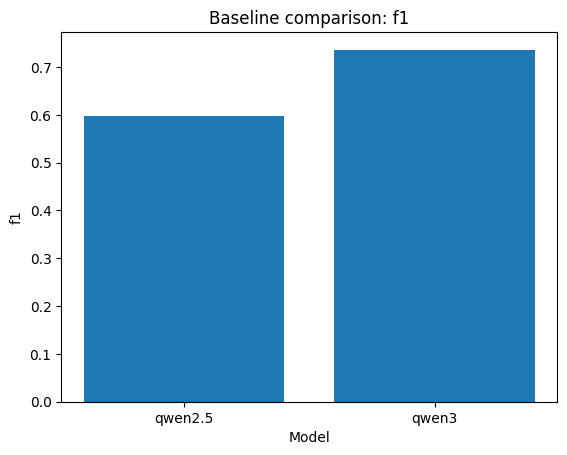

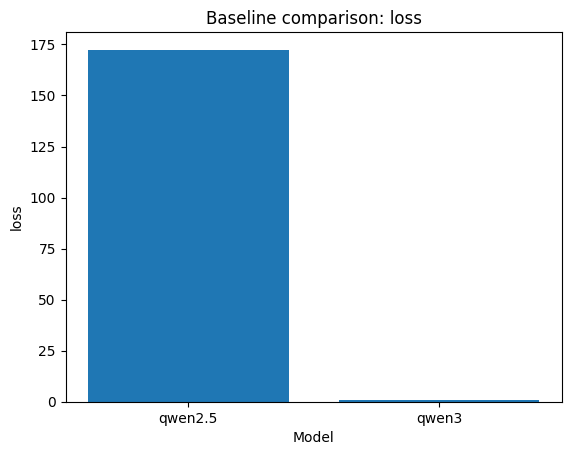

In [30]:
import matplotlib.pyplot as plt

metrics = ['accuracy', 'f1', 'loss']

for metric in metrics:
    plt.figure()

    values = df_base.groupby('model')[metric].mean()

    plt.bar(values.index, values.values)

    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.title(f'Baseline comparison: {metric}')

    plt.show()

/tmp/ipykernel_5665/2671389236.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


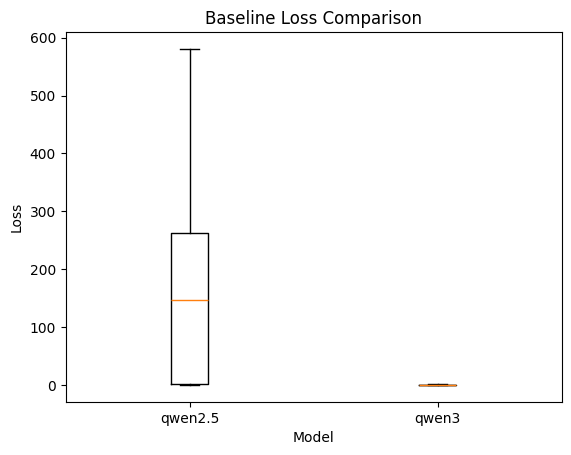

In [31]:
plt.figure()

data = []
labels = []

for model, group in df_base.groupby('model'):
    data.append(group['loss'].dropna())
    labels.append(model)

plt.boxplot(data, labels=labels)

plt.xlabel('Model')
plt.ylabel('Loss')
plt.title('Baseline Loss Comparison')

plt.show()

In [39]:
df_base = df_base[df_base['dataset'] == "EN"]

<Figure size 640x480 with 0 Axes>

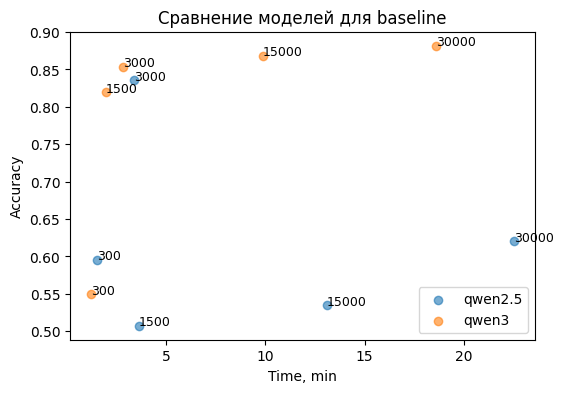

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('all_exp_results.csv')

plt.figure()

size_scale = 1000
fig, ax = plt.subplots(figsize=(6, 4))
for model, group in df_base.groupby('model'):
    plt.scatter(
        group['time'],              # X
        group['accuracy'],               # Y
        #s=group['accuracy'] * size_scale,  # размер
        label=model,
        alpha=0.6
    )

    # Подписи (объем датасета)
    for _, row in group.iterrows():
        plt.text(
            row['time'],
            row['accuracy'],
            str(int(row['pst_dataset'])),
            fontsize=9
        )

plt.xlabel('Time, min')
plt.ylabel('Accuracy')
plt.title('Сравнение моделей для baseline')

plt.legend()
plt.show()

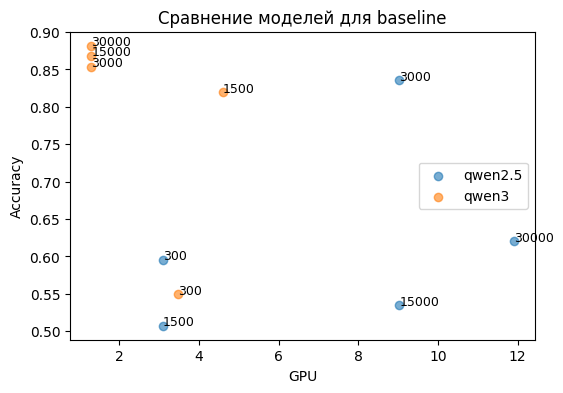

In [52]:
fig, ax = plt.subplots(figsize=(6, 4))
for model, group in df_base.groupby('model'):
    plt.scatter(
        group['gpu'],              # X
        group['accuracy'],               # Y
        #s=group['accuracy'] * size_scale,  # размер
        label=model,
        alpha=0.6
    )

    # Подписи (объем датасета)
    for _, row in group.iterrows():
        plt.text(
            row['gpu'],
            row['accuracy'],
            str(int(row['pst_dataset'])),
            fontsize=9
        )

plt.xlabel('GPU')
plt.ylabel('Accuracy')
plt.title('Сравнение моделей для baseline')

plt.legend()
plt.show()

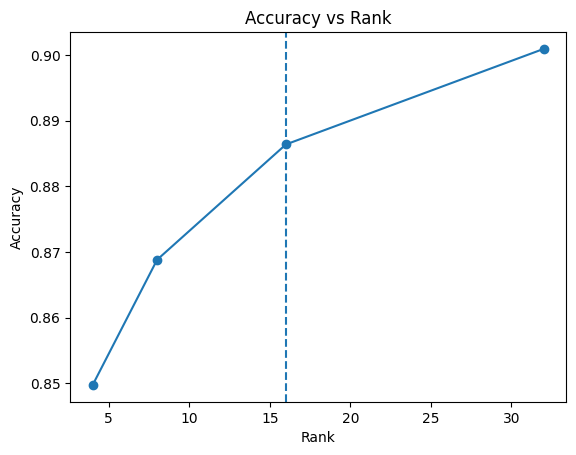

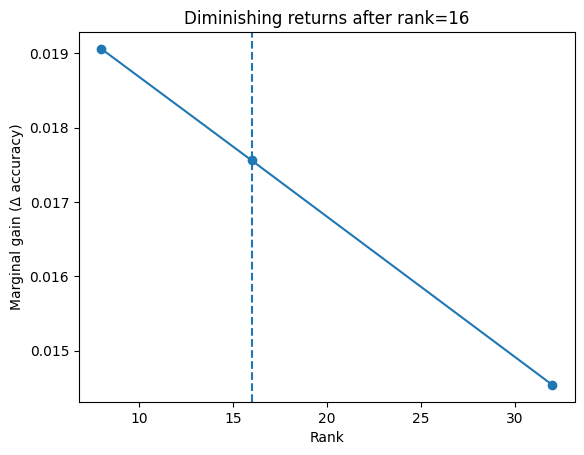

Avg gain before rank=16: 0.018307320366666713
Avg gain after rank=16: 0.014538440588888868


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка
df = pd.read_csv('all_exp_results.csv')

# Фильтр: только LoRA / QLoRA и валидный rank
df_rank = df[
    (df['method'].isin(['LoRA', 'QLoRA nf4', 'QLoRA fp4'])) &
    (df['rank'].notna())
]

# Среднее качество по rank
rank_stats = (
    df_rank
    .groupby('rank')['accuracy']
    .mean()
    .reset_index()
    .sort_values('rank')
)

# Считаем прирост (delta)
rank_stats['delta'] = rank_stats['accuracy'].diff()

# ===== ГРАФИК 1: качество от rank =====
plt.figure()
plt.plot(rank_stats['rank'], rank_stats['accuracy'], marker='o')

plt.axvline(x=16, linestyle='--')  # ключевая граница

plt.xlabel('Rank')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Rank')

plt.show()

# ===== ГРАФИК 2: убывающая отдача =====
plt.figure()
plt.plot(rank_stats['rank'], rank_stats['delta'], marker='o')

plt.axvline(x=16, linestyle='--')

plt.xlabel('Rank')
plt.ylabel('Marginal gain (Δ accuracy)')
plt.title('Diminishing returns after rank=16')

plt.show()

# ===== ЧИСЛОВОЕ ДОКАЗАТЕЛЬСТВО =====
before_16 = rank_stats[rank_stats['rank'] <= 16]['delta'].mean()
after_16 = rank_stats[rank_stats['rank'] > 16]['delta'].mean()

print("Avg gain before rank=16:", before_16)
print("Avg gain after rank=16:", after_16)

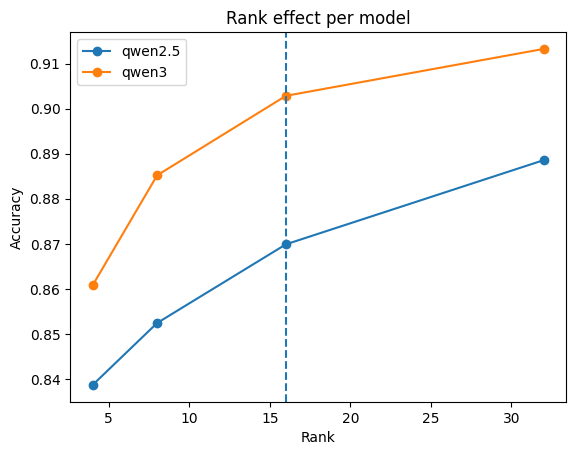

In [ ]:
rank_model = (
    df_rank
    .groupby(['model', 'rank'])['accuracy']
    .mean()
    .reset_index()
)

plt.figure()

for model, group in rank_model.groupby('model'):
    group = group.sort_values('rank')
    plt.plot(group['rank'], group['accuracy'], marker='o', label=model)

plt.axvline(x=16, linestyle='--')

plt.xlabel('Rank')
plt.ylabel('Accuracy')
plt.title('Rank effect per model')
plt.legend()

plt.show()